In [1]:
import pandas as pd
import pygwalker as pyg
import os
import openpyxl

# https://chatgpt.com/g/g-vK4oPfjfp-coding-assistant/c/68bede3a-b80c-8333-8654-72449668a41a

In [31]:
chunk_count = 18832
intervals = 9
gross_outputs = 14
net_outputs = 6

In [3]:
chunk_stats_folder = '/mnt/c/GIS/git/AFOLU_GHG_flux_model/chunk_stats/'
veg_model_parquet_folder = f'{chunk_stats_folder}parquet_20251225_10_05_52_v1_0_4__standard__global__KEEP/'

In [13]:
# Reads gross outputs parquet table
gross_full_df = pd.read_parquet(f'{veg_model_parquet_folder}vegetation_fluxes__v1_0_4__gross_outputs_1x1.parquet')
gross_full_df.head()

,chunk_id,tile_id,layer_name,pattern,years,chunk_name,tile_name,in_out,min_value,mean_value,max_value,count_value,sum_value,data_type,iso
0,-28_-60_-27_-59,50S_030W,gross_emissions__AGC__MgCO2_ha_yr_2016,gross_emissions__AGC__MgCO2_ha_yr,2016,50S_030W__-28_-60_-27_-59__gross_emissions__AG...,50S_030W__gross_emissions__AGC__MgCO2_ha_yr_20...,output_layer,NaN,NaN,NaN,NaN,0.0,no data,SGS
1,-27_-60_-26_-59,50S_030W,gross_emissions__AGC__MgCO2_ha_yr_2016,gross_emissions__AGC__MgCO2_ha_yr,2016,50S_030W__-27_-60_-26_-59__gross_emissions__AG...,50S_030W__gross_emissions__AGC__MgCO2_ha_yr_20...,output_layer,NaN,NaN,NaN,NaN,0.0,no data,SGS
2,177_-60_178_-59,50S_170E,gross_emissions__AGC__MgCO2_ha_yr_2016,gross_emissions__AGC__MgCO2_ha_yr,2016,50S_170E__177_-60_178_-59__gross_emissions__AG...,50S_170E__gross_emissions__AGC__MgCO2_ha_yr_20...,output_layer,NaN,NaN,NaN,NaN,0.0,no data,ATA
3,-27_-59_-26_-58,50S_030W,gross_emissions__AGC__MgCO2_ha_yr_2016,gross_emissions__AGC__MgCO2_ha_yr,2016,50S_030W__-27_-59_-26_-58__gross_emissions__AG...,50S_030W__gross_emissions__AGC__MgCO2_ha_yr_20...,output_layer,NaN,NaN,NaN,NaN,0.0,no data,SGS
4,-27_-58_-26_-57,50S_030W,gross_emissions__AGC__MgCO2_ha_yr_2016,gross_emissions__AGC__MgCO2_ha_yr,2016,50S_030W__-27_-58_-26_-57__gross_emissions__AG...,50S_030W__gross_emissions__AGC__MgCO2_ha_yr_20...,output_layer,NaN,NaN,NaN,NaN,0.0,no data,SGS


In [14]:
# Reads net outputs parquet table
net_full_df = pd.read_parquet(f'{veg_model_parquet_folder}vegetation_fluxes__v1_0_4__net_outputs_1x1.parquet')
net_full_df.head()

,chunk_id,tile_id,layer_name,pattern,years,chunk_name,tile_name,in_out,min_value,mean_value,max_value,count_value,sum_value,data_type,iso
0,-28_-60_-27_-59,50S_030W,net_flux__AGC__MgCO2_ha_yr_2016,net_flux__AGC__MgCO2_ha_yr,2016,50S_030W__-28_-60_-27_-59__net_flux__AGC__MgCO...,50S_030W__net_flux__AGC__MgCO2_ha_yr_2016.tif,output_layer,NaN,NaN,NaN,NaN,0.0,no data,SGS
1,-27_-60_-26_-59,50S_030W,net_flux__AGC__MgCO2_ha_yr_2016,net_flux__AGC__MgCO2_ha_yr,2016,50S_030W__-27_-60_-26_-59__net_flux__AGC__MgCO...,50S_030W__net_flux__AGC__MgCO2_ha_yr_2016.tif,output_layer,NaN,NaN,NaN,NaN,0.0,no data,SGS
2,177_-60_178_-59,50S_170E,net_flux__AGC__MgCO2_ha_yr_2016,net_flux__AGC__MgCO2_ha_yr,2016,50S_170E__177_-60_178_-59__net_flux__AGC__MgCO...,50S_170E__net_flux__AGC__MgCO2_ha_yr_2016.tif,output_layer,NaN,NaN,NaN,NaN,0.0,no data,ATA
3,-27_-59_-26_-58,50S_030W,net_flux__AGC__MgCO2_ha_yr_2016,net_flux__AGC__MgCO2_ha_yr,2016,50S_030W__-27_-59_-26_-58__net_flux__AGC__MgCO...,50S_030W__net_flux__AGC__MgCO2_ha_yr_2016.tif,output_layer,NaN,NaN,NaN,NaN,0.0,no data,SGS
4,-27_-58_-26_-57,50S_030W,net_flux__AGC__MgCO2_ha_yr_2016,net_flux__AGC__MgCO2_ha_yr,2016,50S_030W__-27_-58_-26_-57__net_flux__AGC__MgCO...,50S_030W__net_flux__AGC__MgCO2_ha_yr_2016.tif,output_layer,NaN,NaN,NaN,NaN,0.0,no data,SGS


In [15]:
# Combines gross and net parquet tables into a single table
gross_net_full_df = pd.concat([gross_df_full, net_df_full], ignore_index=True)

In [17]:
# Classifies each row as tropical (30N to 30S) or non-tropical

def is_tropical(chunk_id):
    try:
        parts = chunk_id.split('_')
        second_number = int(parts[1])
        return -30 <= second_number <= 29
    except:
        return False  # Handle bad formatting or missing data

gross_net_full_df['tropical'] = gross_net_full_df['chunk_id'].apply(is_tropical)
# gross_net_full_df[gross_net_full_df['tropical'] == True]

In [18]:
# Groups and sums outputs by country 
gross_net_aggreg_df = gross_net_full_df.groupby(['pattern', 'years', 'iso', 'tropical'], as_index=False)['sum_value'].sum()
# gross_net_aggreg_df

In [21]:
# Exports to a csv so data can be used in Excel or reused
gross_net_aggreg_df.to_csv('/mnt/c/GIS/global_iso_aggreg_1_0_4.csv', index=False)

gross_net_full_wide_df = gross_net_full_df.pivot(
    index=['chunk_id', 'years', 'iso'],
    columns='pattern',
    values='sum_value'
).reset_index()
gross_net_full_wide_df
gross_net_full_wide_df.to_csv('/mnt/c/GIS/global_chunk_v1_0_4_wide.csv', index=False)

Box(children=(HTML(value='<div id="ifr-pyg-1" style="height: auto">\n    <head>\n        <meta http-equiv="Con…


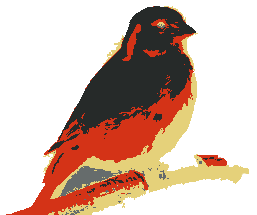

In [23]:
vis_spec = r"""{"config":[{"config":{"defaultAggregated":true,"geoms":["line"],"coordSystem":"generic","limit":-1},"encodings":{"dimensions":[{"dragId":"gw_q1Hs","fid":"pattern","name":"pattern","basename":"pattern","semanticType":"nominal","analyticType":"dimension"},{"dragId":"gw_dtMc","fid":"years","name":"years","basename":"years","semanticType":"temporal","analyticType":"dimension"},{"dragId":"gw_clcc","fid":"iso","name":"iso","basename":"iso","semanticType":"nominal","analyticType":"dimension"},{"dragId":"gw_6zNT","fid":"tropical","name":"tropical","basename":"tropical","semanticType":"nominal","analyticType":"dimension"},{"dragId":"gw_mea_key_fid","fid":"gw_mea_key_fid","name":"Measure names","analyticType":"dimension","semanticType":"nominal"}],"measures":[{"dragId":"gw_dyZG","fid":"sum_value","name":"sum_value","basename":"sum_value","analyticType":"measure","semanticType":"quantitative","aggName":"sum"},{"dragId":"gw_count_fid","fid":"gw_count_fid","name":"Row count","analyticType":"measure","semanticType":"quantitative","aggName":"sum","computed":true,"expression":{"op":"one","params":[],"as":"gw_count_fid"}},{"dragId":"gw_mea_val_fid","fid":"gw_mea_val_fid","name":"Measure values","analyticType":"measure","semanticType":"quantitative","aggName":"sum"}],"rows":[{"dragId":"gw_jgLf","fid":"sum_value","name":"sum_value","basename":"sum_value","analyticType":"measure","semanticType":"quantitative","aggName":"sum"}],"columns":[{"dragId":"gw_wGw3","fid":"years","name":"years","basename":"years","semanticType":"temporal","analyticType":"dimension"}],"color":[{"dragId":"gw_uPga","fid":"pattern","name":"pattern","basename":"pattern","semanticType":"nominal","analyticType":"dimension"}],"opacity":[],"size":[],"shape":[],"radius":[],"theta":[],"longitude":[],"latitude":[],"geoId":[],"details":[],"filters":[],"text":[]},"layout":{"showActions":false,"showTableSummary":false,"stack":"stack","interactiveScale":false,"zeroScale":true,"size":{"mode":"auto","width":320,"height":200},"format":{},"geoKey":"name","resolve":{"x":false,"y":false,"color":false,"opacity":false,"shape":false,"size":false}},"visId":"gw_qEf4","name":"Chart 1"}],"chart_map":{},"workflow_list":[{"workflow":[{"type":"view","query":[{"op":"aggregate","groupBy":["years","pattern"],"measures":[{"field":"sum_value","agg":"sum","asFieldKey":"sum_value_sum"}]}]}]}],"timezoneOffsetSeconds":-18000,"version":"0.3.17"}"""
pyg.walk(gross_net_aggreg_df, spec=vis_spec)

Analysis of single country data

In [24]:
gross_net_df_example_ISO = gross_net_full_df[gross_net_full_df['iso'] == 'RUS']
# gross_net_df_RUS

In [25]:
gross_net_df_example_chunk = gross_net_full_df[gross_net_full_df['chunk_id'] == '124_-25_125_-24']

Box(children=(HTML(value='<div id="ifr-pyg-2" style="height: auto">\n    <head>\n        <meta http-equiv="Con…


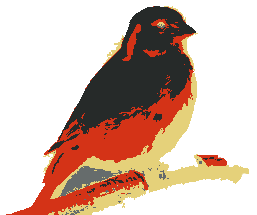

In [26]:
pyg.walk(gross_net_df_example_ISO, spec=vis_spec)

# Core vegetation model parquet QC

In [32]:
# Checks that there are the expected number of rows in the gross flux table
gross_net_full_rows = len(gross_net_full_df)
print(len(gross_net_full_df))
print(gross_net_full_rows == (chunk_count*intervals*(gross_outputs+net_outputs)))

3389760
True


In [34]:
# Reads the dataframe that has global min and max values for all inputs and outputs
min_max_df = pd.read_parquet(f'{veg_model_parquet_folder}vegetation_fluxes__v1_0_4__min_max_for_layers_1x1.parquet')
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.0f}'.format) 
# min_max_df

In [35]:
# Checks that all outputs have the correct number of chunks
all_chunks_present = (min_max_df['count'] == chunk_count).all()
print((min_max_df['count'] == chunk_count).all() == True)

True


In [53]:
# Functions to check min and max values for model inputs and outputs over various scales (chunk or global)
def check_min_max(df, min_max_dict):

    results = {}
    
    for key, (expected_min, expected_max) in min_max_dict.items():
        # Filter rows that match the string
        subset = df[df["layer_name"].str.contains(key)]

        # If 'sum_value' column exists, exclude rows where sum_value == 0 (i.e. there's data)
        if "sum_value" in subset.columns:
            subset = subset[subset["sum_value"] != 0]
    
        # Apply the test
        condition = (subset["min_value"] <= expected_min) & (subset["max_value"] >= expected_max)
    
        # Save result
        results[key] = {
            "all_pass": condition.all(),
            "failing_rows": subset[~condition]  # rows that failed
        }

    return results


def show_min_max_results(extent, results):

    # Show results
    for key, res in results.items():
        print(f"  Min and max for {key} in {extent}: All rows pass--", res["all_pass"])
        if not res["all_pass"]:
            print("  Failing rows:")
            print(res["failing_rows"])

In [58]:
# Checks min and max values for major sets of inputs and outputs (global-- across all chunks) to make sure they match expectations.
# That is, checks the global min and max, not chunk-level min and max. 
# From https://chatgpt.com/g/g-vK4oPfjfp-coding-assistant/c/6952b4f0-2e34-8330-b36a-e373f34f568c

# Input and output patterns and their expected min and max values
global_min_max_dict = {"AGC_emission_factor_CO2_only": [0, 1], "GMWv3_smoothed_mangrove_extent": [0, 1], "burned_area_final": [0, 1], 
                "carbon_density__AGC": [0, 400], "carbon_density__BGC": [0, 300], "carbon_density__deadwood_C": [0, 40], "carbon_density__litter_C": [0, 10],
                "composite_primary_forest": [0, 1], "forest_age_at_end_of_interval": [0, 300], "forest_age_gap_filled_start_year": [6, 305], "gain_year_count_during_interval": [0, 1],
                "gross_emissions__AGC__MgCO2_ha_yr": [0, 1300], "gross_emissions__BGC__MgCO2_ha_yr": [0, 800], "gross_emissions__CH4__MgCO2e_ha_yr": [0, 95], "gross_emissions__N2O__MgCO2e_ha_yr": [0, 25],
                "gross_emissions__deadwood_C__MgCO2_ha_yr": [0, 90], "gross_emissions__litter_C__MgCO2_ha_yr": [0, 40],
                "gross_removals__AGC__MgCO2_ha_yr": [-50, 0], "gross_removals__BGC__MgCO2_ha_yr": [-30, 0], 
                "gross_removals__deadwood_C__MgCO2_ha_yr": [-5, 0], "gross_removals__litter_C__MgCO2_ha_yr": [-0.5, 0],
                "land_cover_composite": [0, 255], "land_state_node": [10200000, 70000000], "max_height_since_last_time_not_tall_veg": [0, 66], "most_recent_year_not_tall_veg": [0, 2015],
                "partial_or_full_dist_in_current_interval": [0, 1], "removal_factor__AGC__MgC_ha_yr": [0, 15], "times_burned_in_current_interval": [0, 1], "vegetation_height": [0, 60],
                # Summative outputs
                "carbon_density__non_soil": [0, 600], 
                "gross_emissions__all_C_pools__CO2_only__MgCO2_ha_yr": [0, 2000], "gross_emissions__all_C_pools__all_gases__MgCO2_ha_yr": [0, 2000], 
                "gross_emissions__all_C_pools__non_CO2_only__MgCO2e_ha_yr": [0, 100], 
                "gross_removals__all_C_pools__MgCO2_ha_yr": [-50, 0], 
                "net_flux__AGC__MgCO2": [-50, 1200], "net_flux__BGC__MgCO2": [-20, 700], "net_flux__all_C_pools__CO2_only__MgCO2": [-50, 2000], "net_flux__all_C_pools__all_gases__MgCO2": [-50, 2000],
                "net_flux__deadwood_C__MgCO2": [-5, 90], "net_flux__litter_C__MgCO2": [-0.5, 40]
               }


min_max_results = check_min_max(min_max_df, global_min_max_dict)

show_min_max_results("global", min_max_results)

  Min and max for AGC_emission_factor_CO2_only in global: All rows pass-- True
  Min and max for GMWv3_smoothed_mangrove_extent in global: All rows pass-- True
  Min and max for burned_area_final in global: All rows pass-- True
  Min and max for carbon_density__AGC in global: All rows pass-- True
  Min and max for carbon_density__BGC in global: All rows pass-- True
  Min and max for carbon_density__deadwood_C in global: All rows pass-- True
  Min and max for carbon_density__litter_C in global: All rows pass-- True
  Min and max for composite_primary_forest in global: All rows pass-- True
  Min and max for forest_age_at_end_of_interval in global: All rows pass-- True
  Min and max for forest_age_gap_filled_start_year in global: All rows pass-- True
  Min and max for gain_year_count_during_interval in global: All rows pass-- True
  Min and max for gross_emissions__AGC__MgCO2_ha_yr in global: All rows pass-- True
  Min and max for gross_emissions__BGC__MgCO2_ha_yr in global: All rows pass

In [78]:
# Checks min and max values for major sets of inputs and outputs for specific chunks to make sure they match expectations.
# That is, checks chunk-level min and max.
# From https://chatgpt.com/g/g-vK4oPfjfp-coding-assistant/c/6952b4f0-2e34-8330-b36a-e373f34f568c

pd.set_option('display.float_format', '{:.4f}'.format) 

# Input and output patterns and their expected min and max values
gross_chunk_dict = { 
                "gross_emissions__AGC__MgCO2_ha_yr": [0, 100], "gross_emissions__BGC__MgCO2_ha_yr": [0, 50], 
                "gross_emissions__CH4__MgCO2e_ha_yr": [0, 10], "gross_emissions__N2O__MgCO2e_ha_yr": [0, 5],
                "gross_emissions__deadwood_C__MgCO2_ha_yr": [0, 3], "gross_emissions__litter_C__MgCO2_ha_yr": [0, 3],
                "gross_removals__AGC__MgCO2_ha_yr": [-10, 0], "gross_removals__BGC__MgCO2_ha_yr": [-10, 0], 
                "gross_removals__deadwood_C__MgCO2_ha_yr": [-0.002, 0], "gross_removals__litter_C__MgCO2_ha_yr": [-0.002, 0],
                # Summative outputs
                "carbon_density__non_soil": [0, 600], 
                "gross_emissions__all_C_pools__CO2_only__MgCO2_ha_yr": [0, 700], "gross_emissions__all_C_pools__all_gases__MgCO2_ha_yr": [0, 700], 
                "gross_emissions__all_C_pools__non_CO2_only__MgCO2e_ha_yr": [0, 20], 
                "gross_removals__all_C_pools__MgCO2_ha_yr": [-10, 0],
                "net_flux__AGC__MgCO2": [-10, 300], "net_flux__BGC__MgCO2": [-10, 100], 
                "net_flux__all_C_pools__CO2_only__MgCO2": [-10, 400], "net_flux__all_C_pools__all_gases__MgCO2": [-10, 400],
                "net_flux__deadwood_C__MgCO2": [-0.02, 4], "net_flux__litter_C__MgCO2": [-0.02, 2]
               }

# chunk_ids = ['24_-8_25_-7', '10_49_11_50']
chunk_ids = ['10_49_11_50']
# chunk_ids = ['24_-8_25_-7']

for chunk_id in chunk_ids:
    print(f"Checking min and max in chunk {chunk_id}:")
    gross_df_chunk = gross_df_full[gross_df_full['chunk_id'] == chunk_id]
    
    min_max_results = check_min_max(gross_df_chunk, gross_chunk_dict)
    
    show_min_max_results(chunk_id, min_max_results)

Checking min and max in chunk 10_49_11_50:
  Min and max for gross_emissions__AGC__MgCO2_ha_yr in 10_49_11_50: All rows pass-- True
  Min and max for gross_emissions__BGC__MgCO2_ha_yr in 10_49_11_50: All rows pass-- True
  Min and max for gross_emissions__CH4__MgCO2e_ha_yr in 10_49_11_50: All rows pass-- True
  Min and max for gross_emissions__N2O__MgCO2e_ha_yr in 10_49_11_50: All rows pass-- True
  Min and max for gross_emissions__deadwood_C__MgCO2_ha_yr in 10_49_11_50: All rows pass-- True
  Min and max for gross_emissions__litter_C__MgCO2_ha_yr in 10_49_11_50: All rows pass-- True
  Min and max for gross_removals__AGC__MgCO2_ha_yr in 10_49_11_50: All rows pass-- True
  Min and max for gross_removals__BGC__MgCO2_ha_yr in 10_49_11_50: All rows pass-- True
  Min and max for gross_removals__deadwood_C__MgCO2_ha_yr in 10_49_11_50: All rows pass-- True
  Min and max for gross_removals__litter_C__MgCO2_ha_yr in 10_49_11_50: All rows pass-- True
  Min and max for carbon_density__non_soil in

In [115]:
%%time

# Compares select gross and corresponding net values for chunks and intervals
# Based on https://chatgpt.com/g/g-vK4oPfjfp-coding-assistant/c/68d561bb-9fdc-832b-9bb0-dd10c4da5c2c

years = gross_df_full['years'].unique()  # Years to compare
unique_chunk_ids = gross_df_full['chunk_id'].unique()  # List of all chunk_ids
unique_chunk_ids = pd.Series(unique_chunk_ids)
unique_chunk_ids = unique_chunk_ids.sample(n=2, random_state=42).tolist()  # Random sample of chunk_ids to compare because 18832 will take about 4 minutes

# Gross vs. summative/net comparisons to conduct. 
# Key is the string to search the gross df patterns for (e.g., AGC emissions, BGC removals).
# Value is the corresponding net/summative value to compare.
# For example gross_emissions retrieves all six gross emissions (AGC, BGC, deadwood, litter, CH4, N2O) and compares with gross_emissions__all_C_pools__all_gases. 
#TODO This isn't working because it's pulling gross and net values from a single df now, and so it's summing the non-summative and summative gross values together, then comparing those with
#the net values. Need to exclude summative gross values from gross_filtered, so it's just AGC, BGC, deadwood, litter, CH4 and N2O and not the summative gross values.
#Not fixing now, though. 
gross_vs_net_comparison_dict = {"gross_emissions": "gross_emissions__all_C_pools__all_gases", 
                                      "gross_removals": "gross_removals__all_C_pools", 
                                      "gross": "net_flux__all_C_pools__all_gases"}

# Iterates across comparisons
for key, value in gross_vs_summative_comparison_dict.items():
    print(f"=== Comparing {key} to {value} ===")

    # Iterates across years
    for year in years:
        print(f"  Comparing {year}")

        # Iterates across sample of chunk_ids
        for chunk_id in unique_chunk_ids:
            # print(f"    Comparing {chunk_id}")

            # Gross df filtered to the relevant values
            gross_filtered = gross_net_full_df[
                gross_net_full_df['pattern'].str.contains(key) &
                (gross_net_full_df['years'] == year) &
                (gross_net_full_df['chunk_id'] == chunk_id)
            ]
            # print(gross_filtered)

            # Summed gross value
            gross_sum_value = gross_filtered['sum_value'].sum()
            # print(gross_sum_value)
            
            # Gets corresponding value from summative table
            net_filtered = gross_net_full_df[
                gross_net_full_df['pattern'].str.contains(value) &
                (gross_net_full_df['years'] == str(year)) & 
                (gross_net_full_df['chunk_id'] == chunk_id)
            ]
            # print(net_filtered)
            
            corresponding_net = net_filtered['sum_value'].sum()
            # print(corresponding_net)
        
            diff = gross_sum_value - corresponding_net
            if abs(diff) < 4:  # The values won't be exactly the same because of floating point errors during summation, so there's a little tolerance here. 
                # print(f"      Gross {key} and net {value} for {year} for {chunk_id}: match ")  # Not printing passes because it slows down the testing and is visually distracting. 
                pass
            else:
                print(f"      Gross {key} and net {value} for {year} for {chunk_id}: do not match by {diff}")
                print(f"      gross filtered: {gross_sum_value}")
                print(gross_filtered)
                print("       corresponding_net:")
                print(corresponding_net)
                
            sys.quit()

=== Comparing gross_emissions to gross_emissions__all_C_pools__all_gases ===
  Comparing 2016
      Gross gross_emissions and net gross_emissions__all_C_pools__all_gases for 2016 for -38_-13_-37_-12: do not match by 973382.003162384
      gross filtered: 1460073.221912384
                chunk_id   tile_id  \
2571     -38_-13_-37_-12  10S_040W   
172059   -38_-13_-37_-12  10S_040W   
341547   -38_-13_-37_-12  10S_040W   
511035   -38_-13_-37_-12  10S_040W   
680523   -38_-13_-37_-12  10S_040W   
850011   -38_-13_-37_-12  10S_040W   
1019499  -38_-13_-37_-12  10S_040W   
1188987  -38_-13_-37_-12  10S_040W   
1358475  -38_-13_-37_-12  10S_040W   

                                                layer_name  \
2571                gross_emissions__AGC__MgCO2_ha_yr_2016   
172059              gross_emissions__BGC__MgCO2_ha_yr_2016   
341547             gross_emissions__CH4__MgCO2e_ha_yr_2016   
511035             gross_emissions__N2O__MgCO2e_ha_yr_2016   
680523   gross_emissions__all_C_pool

NameError: name 'sys' is not defined

# 0.04x0.04 deg chunk-level output vegetation model QC

In [113]:
year = 2017
net_filtered = net_full_df[
    # net_full_df['pattern'].str.contains('gross_emissions__all_C_pools__all_gases') &
    (net_full_df['years'] == str(year)) & 
    (net_full_df['chunk_id'] == '-38_-13_-37_-12')
]
net_filtered

,chunk_id,tile_id,layer_name,pattern,years,chunk_name,tile_name,in_out,min_value,mean_value,max_value,count_value,sum_value,data_type,iso
21403,-38_-13_-37_-12,10S_040W,net_flux__AGC__MgCO2_ha_yr_2017,net_flux__AGC__MgCO2_ha_yr,2017,10S_040W__-38_-13_-37_-12__net_flux__AGC__MgCO...,10S_040W__net_flux__AGC__MgCO2_ha_yr_2017.tif,output_layer,-42.3445,-0.3324,399.6915,1410366.0000,-400160.5625,float32,BRA
190891,-38_-13_-37_-12,10S_040W,net_flux__BGC__MgCO2_ha_yr_2017,net_flux__BGC__MgCO2_ha_yr,2017,10S_040W__-38_-13_-37_-12__net_flux__BGC__MgCO...,10S_040W__net_flux__BGC__MgCO2_ha_yr_2017.tif,output_layer,-16.8904,-0.0978,172.2161,1410355.0000,-117778.7188,float32,BRA
360379,-38_-13_-37_-12,10S_040W,net_flux__all_C_pools__CO2_only__MgCO2_ha_yr_2017,net_flux__all_C_pools__CO2_only__MgCO2_ha_yr,2017,10S_040W__-38_-13_-37_-12__net_flux__all_C_poo...,10S_040W__net_flux__all_C_pools__CO2_only__MgC...,output_layer,-49.5433,-0.4252,506.3394,1410366.0000,-511882.8750,float32,BRA
529867,-38_-13_-37_-12,10S_040W,net_flux__all_C_pools__all_gases__MgCO2e_ha_yr...,net_flux__all_C_pools__all_gases__MgCO2e_ha_yr,2017,10S_040W__-38_-13_-37_-12__net_flux__all_C_poo...,10S_040W__net_flux__all_C_pools__all_gases__Mg...,output_layer,-49.5433,-0.4252,506.3394,1410366.0000,-511882.8750,float32,BRA
699355,-38_-13_-37_-12,10S_040W,net_flux__deadwood_C__MgCO2_ha_yr_2017,net_flux__deadwood_C__MgCO2_ha_yr,2017,10S_040W__-38_-13_-37_-12__net_flux__deadwood_...,10S_040W__net_flux__deadwood_C__MgCO2_ha_yr_20...,output_layer,-2.0092,0.0043,26.7894,28701.0000,5170.6870,float32,BRA
868843,-38_-13_-37_-12,10S_040W,net_flux__litter_C__MgCO2_ha_yr_2017,net_flux__litter_C__MgCO2_ha_yr,2017,10S_040W__-38_-13_-37_-12__net_flux__litter_C_...,10S_040W__net_flux__litter_C__MgCO2_ha_yr_2017...,output_layer,-0.2763,0.0007,4.6875,28701.0000,885.7540,float32,BRA


In [ ]:
min_max_4km = pd.read_excel(f'{chunk_stats_folder}LULUCF_0_04deg_output_by_chunk_1x1_chunk_statistics_20250925_12_20_23__KEEP.xlsx', sheet_name="min_max_for_layers_1x1")
chunk_gross_4km = pd.read_excel(f'{chunk_stats_folder}LULUCF_0_04deg_output_by_chunk_1x1_chunk_statistics_20250925_12_20_23__KEEP.xlsx', sheet_name="gross_outputs_1x1")
# chunk_net_4km = pd.read_excel(f'{chunk_stats_folder}LULUCF_0_04deg_output_by_chunk_1x1_chunk_statistics_20250925_12_20_23__KEEP.xlsx', sheet_name="net_outputs_1x1")
min_max_4km.head()